In [5]:
import pandas as pd 

# Save to files
df_test= pd.read_csv('/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/data/test_courses.csv', encoding='utf-8')
#df_all_courses.to_pickle('/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/data/test_courses.pkl')

print(f"\nDataFrame shape: {df_test.shape}")
print(f"Columns: {df_test.columns.tolist()}")
print("\nFirst row preview:")
print(df_test.head())


DataFrame shape: (29, 9)
Columns: ['title', 'credits', 'level', 'description', 'topics', 'learning_outcomes', 'prerequisites', 'examination_methods', 'course_code']

First row preview:
                                      title credits   level  \
0                          Systems Security  5 ECTS  Master   
1                       Smart Phone Sensing  5 ECTS  Master   
2  Research in Cyber Security – Hacking Lab    5 EC  Master   
3                    Error Correcting Codes    4 EC     MSc   
4                  Distributed Data Systems  5 ECTS     MSc   

                                         description  \
0  The course overviews principles, concepts, met...   
1  The course provides an introduction to the cur...   
2  The security of computer and telecommunication...   
3  Introduction into error-correcting codes; math...   
4  Starting in the mid-1990s, computing is underg...   

                                              topics  \
0  ['Hardware primitives', 'Operating syst

In [6]:
df_LU= pd.read_csv('/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/data/LU/C/all_mandatory_courses.csv', encoding='utf-8')

print(f"\nDataFrame shape: {df_LU.shape}")
print(f"Columns: {df_LU.columns.tolist()}")
print("\nFirst row preview:")
print(df_LU.iloc[0])


DataFrame shape: (175, 9)
Columns: ['title', 'credits', 'level', 'description', 'topics', 'learning_outcomes', 'prerequisites', 'examination_methods', 'course_code']

First row preview:
title                                        Calculus in One Variable B1
credits                                                      7.5 credits
level                                                                BSc
description            The aim of the course is to give a basic intro...
topics                 ['Number concept', 'Calculation with fractions...
learning_outcomes      ['within the framework of the course with conf...
prerequisites                                                         []
examination_methods    ['Written test comprising theory and problem s...
course_code                                                       FMAB65
Name: 0, dtype: object


In [7]:
# load RF 
import joblib 
RF = joblib.load('random_forest_model.pkl')

In [8]:
# Load sBERT tokenizer 
import nltk 
nltk.download('punkt') 
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize 
from sentence_transformers import SentenceTransformer 
import numpy as np 
import torch 
from utils.eval import * 
from utils.embedding import * 

model_name = "sentence-transformers/all-mpnet-base-v2"   # sBERT model
model = SentenceTransformer(model_name)
tokenizer = model.tokenizer
max_tokens = 256  # model limit

# compute cos_sim in learning objectives 
from sklearn.metrics.pairwise import cosine_similarity
import ast 
def embed_objectives(model, objectives):
    if len(objectives) == 0:
        return np.empty((0, model.get_sentence_embedding_dimension()))

    objectives = [normalize(obj) for obj in objectives]

    return model.encode(
        objectives,
        convert_to_numpy=True,
        normalize_embeddings=True   # important for cosine
    )

def extract_sim_matrix_neg(df_TUE, df_OVL, course1, course2, field='topics'):
    result = df_TUE.loc[df_TUE['course_code'] == course1, field] 
    LOs1 = ast.literal_eval(result.iloc[0])
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, field].empty: 
        result = df_TUE.loc[df_TUE['course_code'] == course2, field] 
         
        if not result.iloc[0] == '[]': 
            LOs2 = ast.literal_eval(result.iloc[0])
        else: 
            return np.zeros((2,2))
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, field] 
        
        if not result.iloc[0] == '[]': 
            LOs2 = ast.literal_eval(result.iloc[0])
        else: 
            return np.zeros((2,2))
    # compute similarity 
    emb1 = embed_objectives(model, LOs1)
    emb2 = embed_objectives(model, LOs2)
    # Pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(emb1, emb2)
    return sim_matrix
    #features.append(extract_features(sim_matrix, emb1, emb2))

def extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='topics'):
    result = df_TUE.loc[df_TUE['course_code'] == course1, field] 
    LOs1 =result.iloc[0]
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, field].empty:
        result = df_TUE.loc[df_TUE['course_code'] == course2, field] 
        if not result.empty: 
            LOs2 = result.iloc[0]
        else: 
            return np.zeros((2,2))
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, field] 
        if not result.empty: 
            LOs2 = result.iloc[0]
        else: 
            return np.zeros((2,2))
    # compute similarity 
    emb1 = embed_objectives(model, split_sentences(str(LOs1)))
    emb2 = embed_objectives(model,split_sentences(str(LOs2)))
    # Pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(emb1, emb2)
    return sim_matrix
    #features.append(extract_features(sim_matrix, emb1, emb2))

def extract_features(S): #,embA,embB): 
    maxA = S.max(axis=1)
    maxB = S.max(axis=0)
    # Matching strength overall 
    features = [
        S.mean(),
        S.max(),
        S.std()
    ]
    # Coverage: how much of one course is covered by the other? 
    features.extend([
    (S > 0.5).mean(),
    #(maxB > 0.5).mean(),
    (S > 0.6).mean(),
    #(maxB > 0.6).mean(),
    (S > 0.7).mean(),
    ])
    return features 
 
from nltk.tokenize import PunktTokenizer
def split_sentences(text): 
    # Download the 'punkt' data if you haven't already
    # import nltk
    # nltk.download('punkt')
    
    #text = "Dr. Smith is here. She has a Ph.D. in Chemistry."
    tokenizer = PunktTokenizer()
    sentences = tokenizer.tokenize(text)
    
    return sentences
# Output: ['Dr. Smith is here.', 'She has a Ph.D. in Chemistry.']        

[nltk_data] Downloading package punkt to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [65]:
df_TUE = df_test 
df_OVL = df_LU 
field = 'description' # description worked the best 

all_embs = [] 
all_names = [] 
all_codes = [] 
for course1 in df_test['course_code']: 
    emb = [] 
    for field in ['description']: 
        result = df_TUE.loc[df_TUE['course_code'] == course1, field] 
        try: 
            LOs1 =result.iloc[0]
            embs = embed_objectives(model, split_sentences(str(LOs1))) 
            for embi in embs: 
                emb.append(embi)
        except: 
            continue    
    
    # compute similarity 
    all_embs.append(np.mean(np.array(emb),axis=0))
    all_names.append(df_TUE.loc[df_TUE['course_code'] == course1, 'title'])
    all_codes.append(course1)

for course1 in df_LU['course_code']: 
    emb = [] 
    for field in ['description']: 
        result = df_LU.loc[df_LU['course_code'] == course1, field] 
        try: 
            LOs1 =result.iloc[0]
            embs = embed_objectives(model, split_sentences(str(LOs1))) 
            for embi in embs: 
                emb.append(embi)
        except: 
            continue    
    
    # compute similarity 
    all_embs.append(np.mean(np.array(emb),axis=0))
    all_embs.append(np.mean(emb1,axis=0))
    all_names.append(df_LU.loc[df_LU['course_code'] == course1, 'title'])
    all_codes.append(course1)
print(np.array(all_embs).shape)

(379, 768)


In [66]:
student_list = [[0,1,2,3,4],
                [9,8,7,12,5,10,6,11], # CMPM 26 ontbreekt
                [5,17,15,14,19,18,16],
                [27,21,22,24,20],
                [27,26,20,28]]
student = student_list[0]
print('check courses: ',[all_names[i] for i in student])
chosen = ['EITN41','EITP30','EITN41','EITG05','ETSN11'] # see Test_LU 
chosen_idx = [] 
for chose in chosen: 
    idx = [i for i, code in enumerate(all_codes) if code == chose]
    chosen_idx.append(idx[0])
print(chosen_idx)

check courses:  [0    Systems Security
Name: title, dtype: object, 1    Smart Phone Sensing
Name: title, dtype: object, 2    Research in Cyber Security – Hacking Lab
Name: title, dtype: object, 3    Error Correcting Codes
Name: title, dtype: object, 4    Distributed Data Systems
Name: title, dtype: object]
[103, 78, 103, 76, 49]


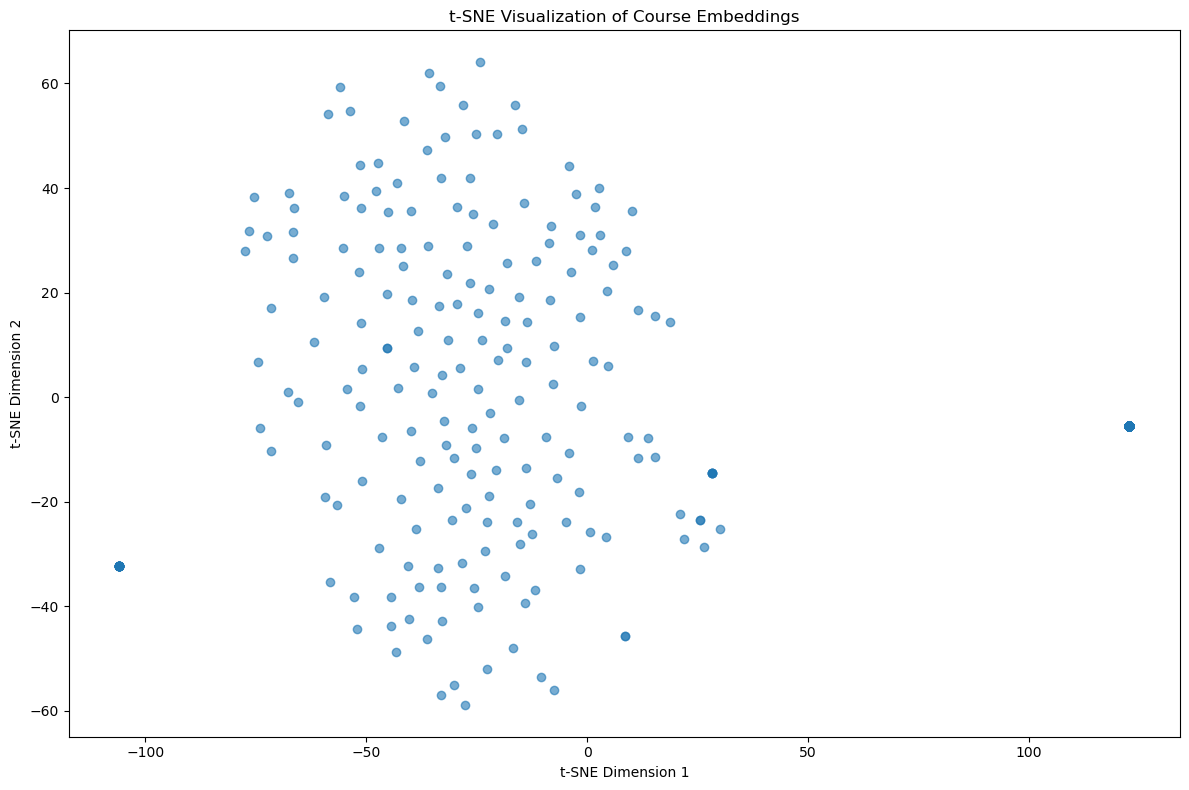

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Assume:
# course_embs = np.array(...)  # shape: (n_courses, embedding_dim)
# course_names = list of strings, length = n_courses

# Step 1: Reduce dimensionality with t‑SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_embs)-1))
embeddings_2d = tsne.fit_transform(np.array(all_embs))

# Step 2: Plot
plt.figure(figsize=(12, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)


plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

Systems Security
yes
Smart Phone Sensing
yes
Research in Cyber Security – Hacking Lab
Error Correcting Codes
yes
Distributed Data Systems
yes


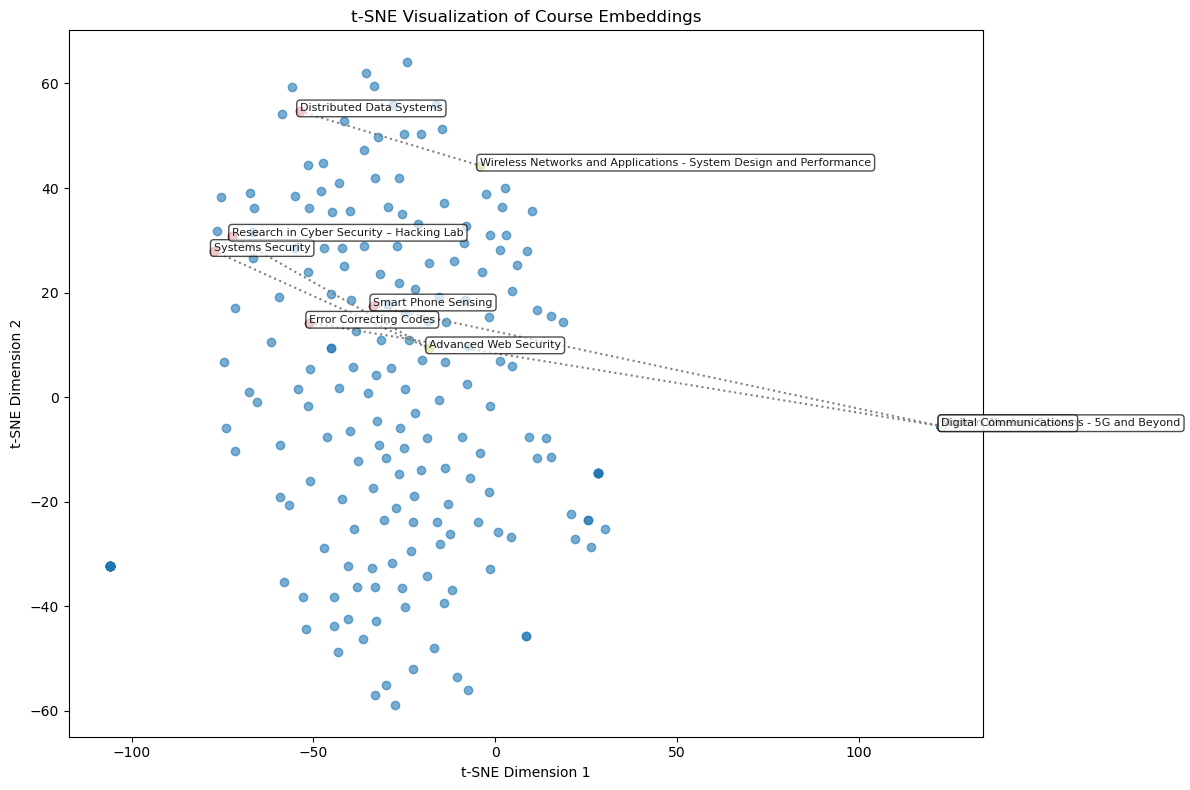

In [72]:
# now visualize t-sne 
from adjustText import adjust_text
plt.figure(figsize=(12, 8))
student = student_list[0]
labels = chosen_idx
#labels = [str(item) for item in chosen_idx]
texts = [] 
lines = [] 
added_labels = []
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
for o,i in enumerate(student): 
    name = all_names[i].iloc[0]
    print(name)
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
    # Store text objects instead of plotting immediately
    texts.append(plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))

    if labels[o] not in added_labels:
        print('yes')
        added_labels.append(labels[o])
        texts.append(plt.annotate(all_names[labels[o]].iloc[0], 
                 (embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1]),
                     fontsize=8,
                     alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))
    plt.scatter(embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1], alpha=0.6,color='y') # not going to be visible 
    xo = np.array([embeddings_2d[i, 0],embeddings_2d[labels[o], 0]])
    yo = np.array([embeddings_2d[i, 1],embeddings_2d[labels[o], 1]])
    line, = plt.plot(xo, yo, linestyle='dotted', color='gray')
    lines.append(line)
        
#adjust_text(texts, 
 #          objects=lines,
 #           expand_points=(0.25, 0.25),
   #         force_points = (3,3))
plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

In [69]:
print(len(all_embs))
labels = chosen_idx 
print(o)
print(chosen_idx[o])

379
4
49


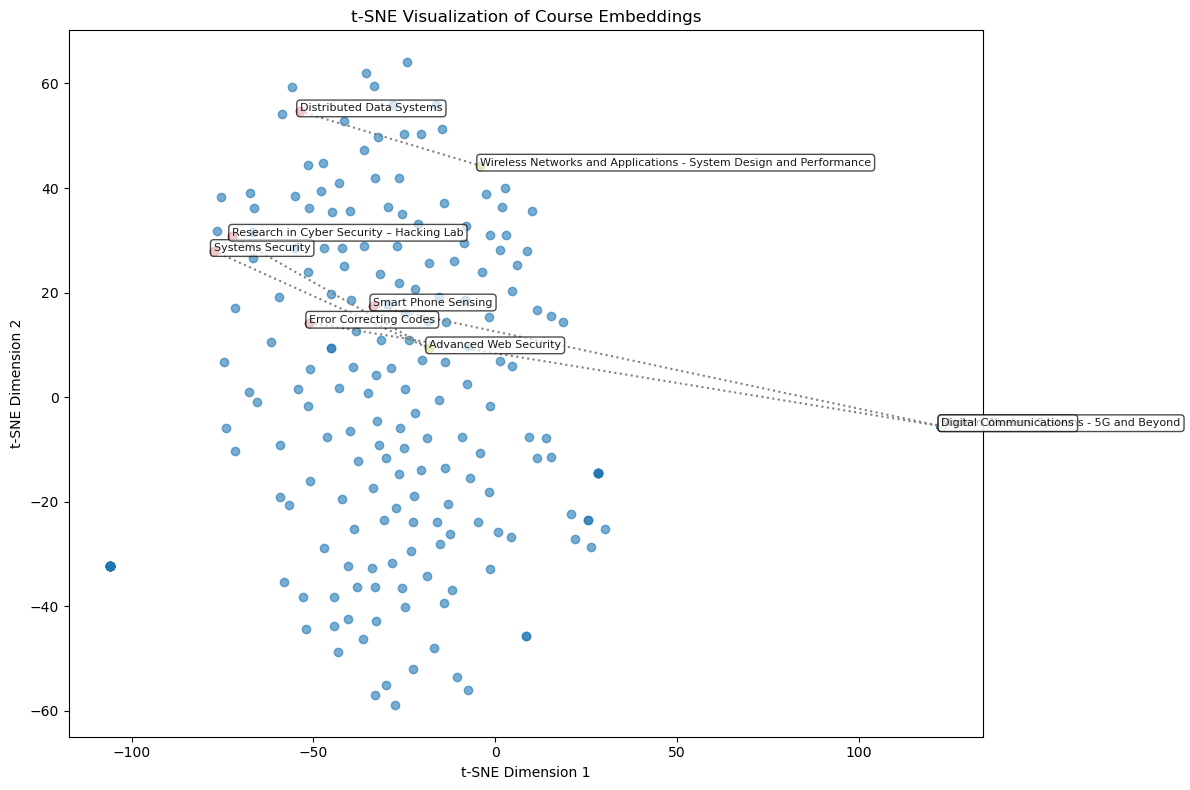

In [73]:
# now visualize t-sne 
from adjustText import adjust_text
plt.figure(figsize=(12, 8))
student = student_list[0]
labels = chosen_idx
#labels = [str(item) for item in chosen_idx]
texts = [] 
lines = [] 
added_labels = []
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
for o,i in enumerate(student): 
    name = all_names[i].iloc[0]
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
    # Store text objects instead of plotting immediately
    texts.append(plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))

    if labels[o] not in added_labels:
        added_labels.append(labels[o])
        texts.append(plt.annotate(all_names[labels[o]].iloc[0], 
                 (embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1]),
                     fontsize=8,
                     alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))
    plt.scatter(embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1], alpha=0.6,color='y') # not going to be visible 
    xo = np.array([embeddings_2d[i, 0],embeddings_2d[labels[o], 0]])
    yo = np.array([embeddings_2d[i, 1],embeddings_2d[labels[o], 1]])
    line, = plt.plot(xo, yo, linestyle='dotted', color='gray')
    lines.append(line)
        
#adjust_text(texts, 
 #          objects=lines,
 #           expand_points=(0.25, 0.25),
   #         force_points = (3,3))
plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

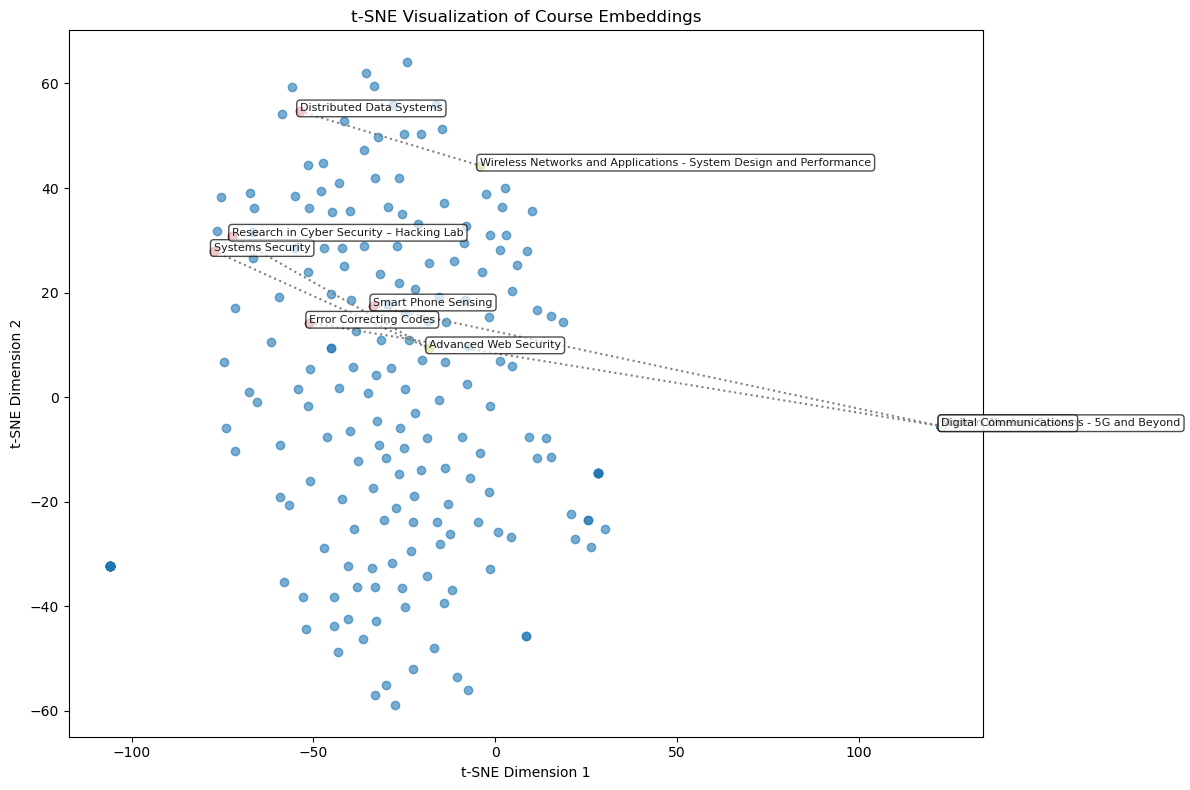

In [74]:
# now visualize t-sne 
from adjustText import adjust_text
plt.figure(figsize=(12, 8))
student = student_list[0]
labels = chosen_idx
#labels = [str(item) for item in chosen_idx]
texts = [] 
lines = [] 
added_labels = []
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
for o,i in enumerate(student): 
    name = all_names[i].iloc[0]
    #print(name)
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], alpha=0.6,color='r')
    # Store text objects instead of plotting immediately
    texts.append(plt.annotate(name, 
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=8,
                 alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))

    if labels[o] not in added_labels:
        #print('yes')
        added_labels.append(labels[o])
        texts.append(plt.annotate(all_names[labels[o]].iloc[0], 
                 (embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1]),
                     fontsize=8,
                     alpha=0.9,
                               bbox=dict(boxstyle='round,pad=0.3', 
                                       facecolor='white', 
                                       alpha=0.7)))
    plt.scatter(embeddings_2d[labels[o], 0], embeddings_2d[labels[o], 1], alpha=0.6,color='y') # not going to be visible 
    xo = np.array([embeddings_2d[i, 0],embeddings_2d[labels[o], 0]])
    yo = np.array([embeddings_2d[i, 1],embeddings_2d[labels[o], 1]])
    line, = plt.plot(xo, yo, linestyle='dotted', color='gray')
    lines.append(line)
        
#adjust_text(texts, 
 #          objects=lines,
 #           expand_points=(0.25, 0.25),
   #         force_points = (3,3))
plt.title('t‑SNE Visualization of Course Embeddings')
plt.xlabel('t‑SNE Dimension 1')
plt.ylabel('t‑SNE Dimension 2')
plt.tight_layout()
plt.show()

In [42]:
print(type(chosen_idx))
print(type(labels))
for i, x in enumerate(labels):
    if not isinstance(x, (str, int, float)):
        print(i, type(x))

<class 'list'>
<class 'list'>
